In [5]:
import numpy as np
import matplotlib.pyplot as plt
import UMPA

In [6]:
import numpy as np

Npixeles = 256

refs = []
samps = []

for i in range(1, 21):  # ajusta el rango real que necesites
    print('reading reference_2nd_{}.txt'.format(i))

    # np.loadtxt, NO np.fromfile -- el archivo es texto ASCII, no binario
    data_ref = np.loadtxt("Sphere_Geant4/reference_2nd_{}.txt".format(i), dtype='float32')
    refs.append(data_ref.reshape(Npixeles, Npixeles))

    # ajusta el nombre real de tu archivo de muestra
    data_samp = np.loadtxt("Sphere_Geant4/sample_2nd_{}.txt".format(i), dtype='float32')
    samps.append(data_samp.reshape(Npixeles, Npixeles))

refs = np.array(refs)
samps = np.array(samps)
print(refs.shape, samps.shape)   # ahora debería dar (20, 256, 256) (20, 256, 256)

reading reference_2nd_1.txt
reading reference_2nd_2.txt
reading reference_2nd_3.txt
reading reference_2nd_4.txt
reading reference_2nd_5.txt
reading reference_2nd_6.txt
reading reference_2nd_7.txt
reading reference_2nd_8.txt
reading reference_2nd_9.txt
reading reference_2nd_10.txt
reading reference_2nd_11.txt
reading reference_2nd_12.txt
reading reference_2nd_13.txt
reading reference_2nd_14.txt
reading reference_2nd_15.txt
reading reference_2nd_16.txt
reading reference_2nd_17.txt
reading reference_2nd_18.txt
reading reference_2nd_19.txt
reading reference_2nd_20.txt
(20, 256, 256) (20, 256, 256)


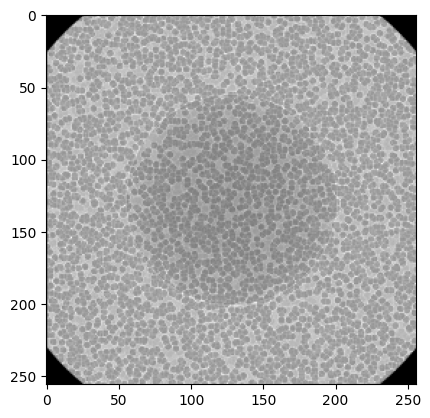

In [7]:
plt.imshow(samps[0], cmap='gray')

In [ ]:
UMPA_res2 = UMPA.match(samps, refs, 1,max_shift=1) # provide sample and reference images in input to #UMPA, 3 is the window size (user defined)
UMPA_bias2 = UMPA.match(refs, refs, 1,max_shift=1)

Using 16 threads
Using 16 threads


/tmp/ipykernel_1455773/2692403090.py:18: MatplotlibDeprecationWarning: Auto-removal of overlapping axes is deprecated since 3.6 and will be removed two minor releases later; explicitly call ax.remove() as needed.
  plt.subplot(4,4,1)


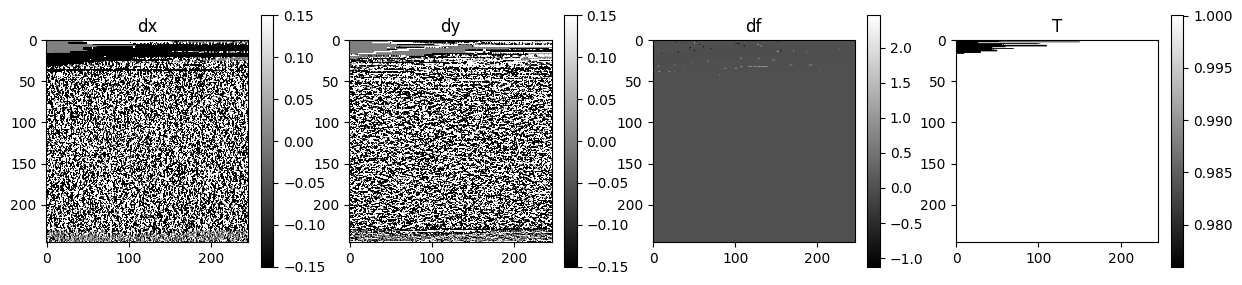

In [5]:
dx = UMPA_res2['dx']-UMPA_bias2['dx']
#np.savetxt(f'FS_Measurements_txt_Files/dx_SiC_60um_FS{FS_Size}um_21kev_2x150_75_AIR.txt', dx, fmt='%f')
dy = UMPA_res2['dy']-UMPA_bias2['dy']
#np.savetxt(f'FS_Measurements_txt_Files/dy_SiC_60um_FS{FS_Size}um_21kev_2x150_75_AIR.txt', dy, fmt='%f')
df = UMPA_res2['df']-UMPA_bias2['df']
T = UMPA_res2['T']
#np.savetxt(f'FS_Measurements_txt_Files/T_SiC_60um_FS{FS_Size}um_21kev_2x150_75_AIR.txt', T, fmt='%f')
from scipy.ndimage import gaussian_filter
dx = gaussian_filter(dx, sigma=0)  # Aplicar filtro gaussiano para suavizar
dy = gaussian_filter(dy, sigma=0)  # Aplicar filtro gaussiano

#np.savetxt("Golden_Results/dx_TiC_90um_19k_PMMA.txt", dx)
#np.savetxt("Golden_Results/dy_TiC_90um_19k_PMMA.txt", dy)
vmin = -0.15
vmax = 0.15
plt.figure(figsize=(15,15))
plt.title('UMPA results at 19kev and 1e9 events')
plt.subplot(4,4,1)
plt.imshow(-dx,cmap='gray',vmin=vmin,vmax=vmax) #here subtract bias to the result -UMPA_bias['dx']
#np.savetxt('dx_4_90.txt', UMPA_res['dx']-UMPA_bias['dx'])
plt.title('dx')
plt.colorbar()
plt.subplot(4,4,2)
plt.imshow(-dy,cmap='gray',vmin=vmin,vmax=vmax) #-UMPA_bias['dy']
plt.title('dy')
#np.savetxt('dy_4_90.txt', UMPA_res['dy']-UMPA_bias['dy'])
plt.colorbar()
plt.subplot(4,4,3)
plt.imshow(df,cmap='gray') #-UMPA_bias['T']
plt.title('df')  
plt.colorbar()
plt.subplot(4,4,4)
plt.imshow(T,cmap='gray') #-UMPA_bias['T']
plt.title('T')  
plt.colorbar()


In [1]:
import numpy as np 
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from scipy.optimize import curve_fit
from scipy.stats import t
import PIL
from scipy.special import erf
plt.rcParams['font.family']='serif'
import os 
from matplotlib_scalebar.scalebar import ScaleBar

Npixeles=256
NI=1 #Número de imágenes RAW
NF=1 #Número de imágenes FF
NThr=1 #Número de imágenes contenidas dentro de cada .raw: La primera es la dada por el canal 0 y la segunda es la dada por el canal 1.
nameRAW1="RAWS/Esfera_Samp_" #RAWS/Esfera_Ref_1__d0.75m_a15um_p62um_step-4.2_dith23.25_1.raw
nameRAW2 = "__d0.75m_a15um_p62um_step-4.2_dith23.25_" 
nameRAW4 = "RAWS/Esfera_Ref_"


In [4]:
def ImagenesR(name,Npixeles):
    I=[]
    for k in range(0,len(name),Npixeles*Npixeles):
        Im=np.zeros((Npixeles,Npixeles))
        for j in range(Npixeles):
            for i in range(Npixeles):
                Im[j,i]=name[i+Npixeles*j+k]
        I.append(Im)
    return I
def Imagenes(name,Npixeles,NI):
    D=[]
    for i in range(1,NI+1):
        Raw=np.fromfile(name+"{}.raw".format(i), dtype='float32')
        K=ImagenesR(Raw,Npixeles)
        D.append(K)
    return D
def sumar_imagenes(name1, name2, Npixeles):
    # Inicializar una matriz para almacenar la suma de las imágenes
    suma_imagenes = np.zeros((Npixeles, Npixeles), dtype='float32')
    
    # Iterar sobre las imágenes (de R00 a R09)
    for i in range(1,3):  # Cambiado a 10 para incluir R00 a R09
        # Construir el nombre del archivo
        nombre_archivo = f"{name1}{i:01d}{name2}1.raw"
        
        # Leer la imagen desde el archivo .raw
        Raw = np.fromfile(nombre_archivo, dtype='float32')
        
        # Convertir la imagen en una matriz 2D
        K = ImagenesR(Raw, Npixeles)
        
        # Sumar la imagen actual a la suma acumulada
        suma_imagenes += K[0]  # Asumiendo que K[0] es la matriz 2D de la imagen
    
    return suma_imagenes
def Imagenes2(name1, name2, Npixeles, NI):    
    D = []
    for i in range(1,21,1):
        Raw = np.fromfile(name1 + "{}".format(i) + name2 + "1.raw", dtype='float32')
        K = ImagenesR(Raw, Npixeles)
        D.append(K[0])#[25:225,25:225])  # Append the first image in the list to avoid extra dimension
    return D
def ImagenesA(name,Npixeles,NI,NThr):
    A=[]
    for i in range(NThr):
        Mean=np.zeros((Npixeles, Npixeles))
        for j in range (NI):
            Mean=Mean+name[j][i]
        A.append(Mean)
    return A
def CNR(meanS,meanB,stdB):
    CNR = (meanB - meanS)/stdB
    return CNR
'''
def copiar_imagenes(base_name, start, end):
    for i in range(start, end + 1):
        new_name = base_name.replace('TiC3', f'TiC{i}')
        os.system(f'cp {base_name} {new_name}')

    # Uso de la función para copiar la imagen con los nuevos nombres
#base_name = 'TiC_PMMA_4Sands/test_PMMA4_TiC3_19kev_R09__d0.1m_a15um_p62um_step-4.2_dith23.25_1.raw'
#copiar_imagenes(base_name, 3, 10)
'''
RAW = Imagenes2(nameRAW1,nameRAW2,Npixeles,NI)
#RAW2 = Imagenes2(nameRAW1,nameRAW3,Npixeles,NI)
REF = Imagenes2(nameRAW4,nameRAW2,Npixeles,NI)
REF = np.array(REF)
RAW = np.array(RAW)


(20, 256, 256)


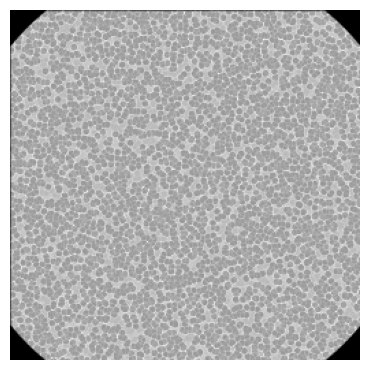

In [9]:
plt.figure(figsize=(10,10))
plt.subplot(2,2,1)
plt.imshow(REF[1]
           ,cmap='gray')
#plt.colorbar()
plt.axis('off')
'''
plt.subplot(2,2,2)
plt.imshow(REF[0],cmap='bone')
plt.colorbar()
plt.subplot(2,2,3)
plt.imshow(RAW[17]/REF[17],cmap='bone')
plt.colorbar()
print(RAW.shape,REF.shape)
plt.subplot(2,2,4)
plt.plot(np.mean((RAW[0]/REF[0]),axis=0), label='Profile mean')
'''
print(RAW.shape)
np.savetxt(f'Mono_sphere_28kev/Sample.txt', RAW[0], fmt='%f')

/tmp/ipykernel_1481676/3986161698.py:4: RuntimeWarning: divide by zero encountered in divide
  plt.imshow(RAW[i]/REF[i],cmap='bone')
/tmp/ipykernel_1481676/3986161698.py:4: RuntimeWarning: invalid value encountered in divide
  plt.imshow(RAW[i]/REF[i],cmap='bone')


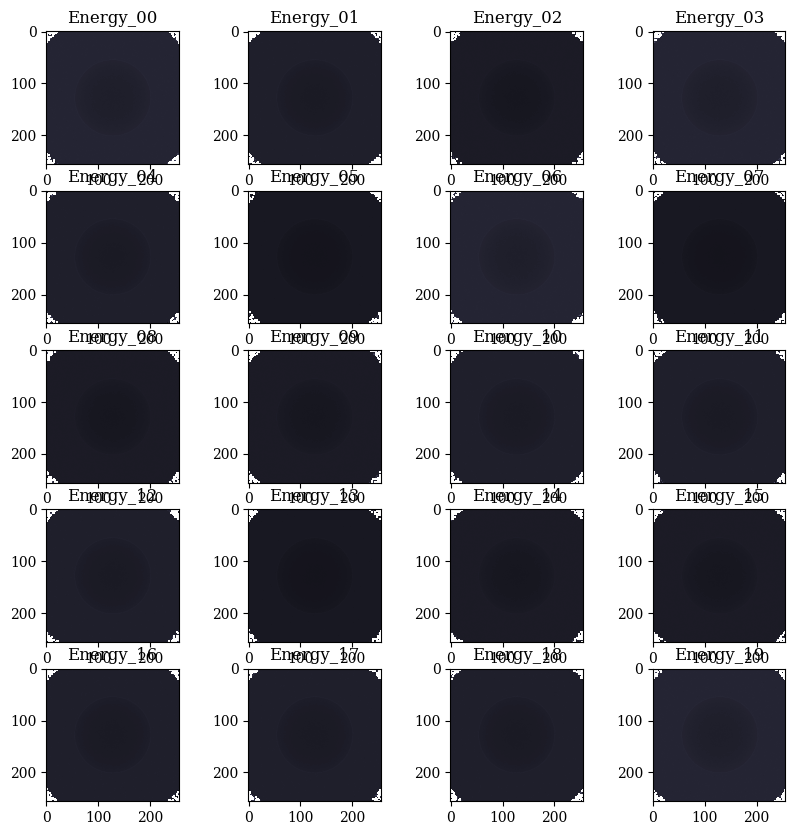

In [5]:
plt.figure(figsize=(10,10))
for i in range(20):
    plt.subplot(5,4,i+1)
    plt.imshow(RAW[i]/REF[i],cmap='bone')
    plt.title(f'Energy_{i:02d}')

Using 16 threads
Using 16 threads
(246, 246)


/tmp/ipykernel_1481676/2129616011.py:53: MatplotlibDeprecationWarning: Auto-removal of overlapping axes is deprecated since 3.6 and will be removed two minor releases later; explicitly call ax.remove() as needed.
  plt.subplot(4,4,1)


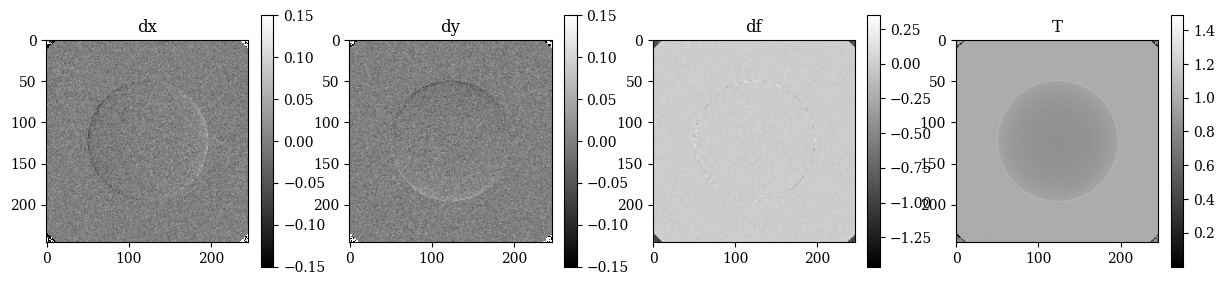

In [8]:
import UMPA
I_ref,Isamp = [],[]
FS_Size = 300
ref = REF# Establishing empty arrays to put SB-PCXI data into
sam = RAW#np.load(f"DATA_Prosesada_14.75keV/RAW_FF_14.75keV.npy")


UMPA_res2 = UMPA.match(sam, ref, 1,max_shift=1) # provide sample and reference images in input to #UMPA, 3 is the window size (user defined)
UMPA_bias2 = UMPA.match(ref, ref, 1,max_shift=1) # UMPA sometimes can output images with a #sistematic bias: you can compute this by taking UMPA result from ref Vs ref
#UMPA_res2 = UMPA.match(np.expand_dims(sam[0],axis=0), np.expand_dims(ref[0],axis=0), 4,max_shift=10) # provide sample and reference images in input to #UMPA, 3 is the window size (user defined)
#UMPA_bias2 = UMPA.match(np.expand_dims(ref[0],axis=0), np.expand_dims(ref[0],axis=0), 4,max_shift=10) 
def inverse_grad(grad_x: np.ndarray, grad_y: np.ndarray, epsilon: float = 1e-6) -> np.ndarray:
    """
    Reconstruye la fase (phi_UMPA) a partir de los gradientes (grad_x, grad_y).
    Basado en la ecuación de Poisson: ∇²ϕ = ∇·G, donde G = (grad_x, grad_y).
    """
    rows, cols = grad_x.shape
    ky, kx = np.mgrid[-rows//2:rows//2, -cols//2:cols//2]
    kx = (2 * np.pi * kx) / cols
    ky = (2 * np.pi * ky) / rows

    # Divergencia del campo de gradientes (∇·G)
    div_G = np.fft.fft2(grad_x) * 1j * kx + np.fft.fft2(grad_y) * 1j * ky

    # Resuelve la ecuación de Poisson en espacio Fourier (evita división por cero)
    kernel = kx**2 + ky**2 + epsilon
    kernel[kernel == 0] = epsilon  # Regularización
    phi_fft = div_G / kernel

    # Transformada inversa para obtener la fase reconstruida
    phi_UMPA = np.fft.ifft2(phi_fft).real
    return phi_UMPA 
phi = inverse_grad(UMPA_res2['dx'], UMPA_res2['dy'],epsilon=1e-4)
print(phi.shape)
#guardar imagenes en formato .txt
dx = UMPA_res2['dx']-UMPA_bias2['dx']
np.savetxt(f'FS_Measurements_txt_Files/dx_SiC_60um_FS{FS_Size}um_21kev_2x150_75_AIR.txt', dx, fmt='%f')
dy = UMPA_res2['dy']-UMPA_bias2['dy']
np.savetxt(f'FS_Measurements_txt_Files/dy_SiC_60um_FS{FS_Size}um_21kev_2x150_75_AIR.txt', dy, fmt='%f')
df = UMPA_res2['df']-UMPA_bias2['df']
T = UMPA_res2['T']
np.savetxt(f'FS_Measurements_txt_Files/T_SiC_60um_FS{FS_Size}um_21kev_2x150_75_AIR.txt', T, fmt='%f')
from scipy.ndimage import gaussian_filter
dx = gaussian_filter(dx, sigma=0)  # Aplicar filtro gaussiano para suavizar
dy = gaussian_filter(dy, sigma=0)  # Aplicar filtro gaussiano

#np.savetxt("Golden_Results/dx_TiC_90um_19k_PMMA.txt", dx)
#np.savetxt("Golden_Results/dy_TiC_90um_19k_PMMA.txt", dy)
vmin = -0.15
vmax = 0.15
plt.figure(figsize=(15,15))
plt.title('UMPA results at 19kev and 1e9 events')
plt.subplot(4,4,1)
plt.imshow(-dx,cmap='gray',vmin=vmin,vmax=vmax) #here subtract bias to the result -UMPA_bias['dx']
#np.savetxt('dx_4_90.txt', UMPA_res['dx']-UMPA_bias['dx'])
plt.title('dx')
plt.colorbar()
plt.subplot(4,4,2)
plt.imshow(-dy,cmap='gray',vmin=vmin,vmax=vmax) #-UMPA_bias['dy']
plt.title('dy')
#np.savetxt('dy_4_90.txt', UMPA_res['dy']-UMPA_bias['dy'])
plt.colorbar()
plt.subplot(4,4,3)
plt.imshow(df,cmap='gray') #-UMPA_bias['T']
plt.title('df')  
plt.colorbar()
plt.subplot(4,4,4)
plt.imshow(T,cmap='gray') #-UMPA_bias['T']
plt.title('T')  
plt.colorbar()
